Encoder:

Residual connection around each of the multi-head attention and feed-forward layers in a transformer block.
Followed by layer normalization.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy

In [4]:
def attention(query, key, value, mask=None, dropout=None):
    """Scaled Dot-Product Attention
                     ▲
        ┌────────────┴─────────────┐
        │4) MatMul                 │ ← Attention Weights · V
        └────▲──────────────────▲──┘
        ┌────┴──────┐           │  
        │3) Softmax │           │
        └────▲──────┘           │
       ┌─────┴────────┐         │
       │2) Mask (opt.)│         │
       └─────▲────────┘         │
        ┌────┴──────┐           │
        │1) Scale   │ (/ √d_k)  │
        └────▲──────┘           │
        ┌────┴──────┐           │
        │1) MatMul  │ ← Q · Kᵀ  │
        └────▲──────┘           │
       ┌─────┴─────┐────────────│ 
       Q           K            V
    """
    print(f"+AT: q/k/v shapes: {query.shape}")
    d_k = query.size(-1)
    # input: query, key, value shape: (batch_size, h, seq_len, d_k)
    #
    # 1) MatMul(QK^T) + Scale(math.sqrt(d_k)) (scaled dot-product):
    #    (batch_size, h, seq_len, d_k) - > (batch_size, h, seq_len, seq_len)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    #
    # 2) Mask optional for decoder
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    print(f"\tscores shape: {scores.shape}")
    #
    # 3) softmax (batch_size, h, seq_len, seq_len) -> (batch_size, h, seq_len, seq_len)
    attn = F.softmax(scores, dim=-1)
    print(f"\tattn shape: {scores.shape}")
    if dropout is not None:
        attn = dropout(attn)
    #
    # 4) MatMul(AV) (batch_size, h, seq_len, seq_len) * (batch_size, h, seq_len, d_k) -> (batch_size, h, seq_len, d_k)
    #    (d_v == d_k == d_model // h)
    out = torch.matmul(attn, value)    
    print(f"-AT: output shape:{out.shape}")
    return out, attn

class MultiHeadAttention(nn.Module):
    """Multi-head attention: d_model dimensional, h heads
                           ┌─────────┐
                           │ Linear  │
                           └────▲────┘
                                │
                           ┌────┴────┐
                           │ Concat  │
                           └────▲────┘
                                │
        ┌─────────────────────────────────────────┐
        │     Scaled Dot-Product Attention        │   × h
        └─────────────────────────────────────────┘
             ▲                ▲                ▲
             │                │                │
         ┌───┴───┐        ┌───┴───┐        ┌───┴───┐
         │ Linear│        │ Linear│        │ Linear│
         └───▲───┘        └───▲───┘        └───▲───┘
             │                │                │
             V                K                Q
    """
    def __init__(self, d_model, h, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % h == 0
        self.h = h
        self.d_k = d_model // h
        # 4 linear layers: Q, K, V projections + output projection
        self.linears = nn.ModuleList([nn.Linear(in_features=d_model, out_features=d_model) for _ in range(4)])
        self.dropout = nn.Dropout(p=dropout)
        # store the probability score for visualization
        self.attn = None
    
    def forward(self, query, key, value, mask=None):
        print(f"+MHA:{list(query.shape)}")
        # query, key, value shape (batch_size, seq_len, d_model)
        batch_size = query.size(0)
        # 1) Linear projections
        #    q_p, k_p, v_p shape (batch_size, h, seq_len, d_k)
        q_p, k_p, v_p = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
                        for l, x in zip(self.linears, (query, key, value))]
        # 2) h times attention (in parallel)
        # concat_attn shape (batch_size, h, seq_len, d_k)
        concat_attn, self.attn = attention(q_p, k_p, v_p, mask, self.dropout)
        # 3) Concat
        # reshape to (batch_size, seq_len, h, d_k)
        concat_attn = concat_attn.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        # concat to (batch_size, seq_len, d_model(h * d_k))
        # concat_attn = concat_attn.view(batch_size, -1, self.h * self.d_k)
        # 4) linear
        # out shape (batch_size, seq_len, d_model)
        out = self.linears[-1](concat_attn)
        print(f"-MHA: output shape:{list(out.shape)}")
        return out

In [5]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear_1 = nn.Linear(in_features=d_model, out_features=d_ff) # w_1 and b_1
        self.linear_2 = nn.Linear(in_features=d_ff, out_features=d_model) # w_2 and b_2
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        print(f"+FFN: x.shape:{x.shape}")
        h1 = self.linear_1(x)
        h2 = self.dropout(torch.relu(h1))
        out_ffn = self.linear_2(h2)
        print(f"-FFN:out shape:{out_ffn.shape}")
        return out_ffn

In [6]:
# Layer normalization
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(features)) # alpha is a learnable parameter
        self.bias = nn.Parameter(torch.zeros(features)) # bias is a learnable parameter

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        # mean shape: (batch, seq_len, 1)
        print(f"+LN x shape:{x.shape}")
        mean = x.mean(-1, keepdim=True)
        print(f"\tLN: mean shape: {mean.shape}")
        # std shape: (batch, seq_len, 1)
        std = x.std(-1, keepdim=True, unbiased=False)
        print(f"\tLN: std shape: {mean.shape}")
        output_n = self.weight * (x - mean) / (std + self.eps) + self.bias
        print(f"-LN output shape:{output_n.shape}")
        return output_n

In [7]:
batch_size, seq_len, features = 1, 10, 512
x = torch.randn(batch_size, seq_len, features)
print(f"input:{x.shape}")
LN = LayerNorm(features)
print(f"LN.w:{LN.weight.shape} LN.bias:{LN.bias.shape}")
y = LN(x)
print(f"Output:{y.shape}")

input:torch.Size([1, 10, 512])
LN.w:torch.Size([512]) LN.bias:torch.Size([512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
Output:torch.Size([1, 10, 512])


In [8]:
from collections.abc import Callable

class ResidualConnection(nn.Module):
    def __init__(self, features: int, dropout: float = 0.1):
        super(ResidualConnection, self).__init__()
        self.norm = LayerNorm(features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer: Callable):
        print(f"+RC: x.shape={x.shape}")
        # out_rc = self.norm(x + self.dropout(sublayer(x)))
        # POST-NORM vs PRE-NORM: 
        # This implementation uses PRE-NORM (norm before sublayer)
        # but the original transform paper used POST-NORM (norm after addition):
        #     Input (x)
        #    |
        #    ├─────────────────┐
        #    |                 |
        #    |            Sublayer(x)
        #    |                 |
        #    |             Dropout
        #    |                 |
        #    └────── (+) ──────┘
        #           |
        #      LayerNorm
        #           |
        #        Output
        # LayerNorm(x + Sublayer(x))
        # out_rc = self.norm(x + self.dropout(sublayer(x)))
        #
        # Modern Implementation: Pre-Norm (LayerNorm BEFORE sublayer)
        # often works better in practice
        # x + Sublayer(LayerNorm(x))
        #
        #     Input (x)
        #    |
        #    ├─────────────────┐
        #    |                 |
        #    |            LayerNorm
        #    |                 |
        #    |            Sublayer
        #    |                 |
        #    |             Dropout
        #    |                 |
        #    └────── (+) ──────┘
        #           |
        #        Output
        #
        # ================================================================================
        # KEY DIFFERENCES
        # ================================================================================

        # Aspect                    Post-Norm (Paper)              Pre-Norm (Modern)             
        # --------------------------------------------------------------------------------
        # Normalization Position    After residual addition        Before sublayer               
        # Gradient Flow             Through normalization          Direct path via residual      
        # Training Stability        Can be unstable                More stable                   
        # Learning Rate             Needs warmup                   Less sensitive                
        # Convergence               Slower initially               Faster convergence            
        # Final Performance         Slightly better (sometimes)    Slightly worse (sometimes)    
        # Ease of Training          Harder                         Easier                        

        out_rc = x + self.dropout(sublayer(self.norm(x)))
        print(f"-RC: output shape: {out_rc.shape}")
        return out_rc
        

In [9]:
print("="*80)
print("LAYER NORMALIZATION: POST-NORM vs PRE-NORM")
print("="*80)
print()

# ============================================================
# Original Paper: Post-Norm (LayerNorm AFTER residual)
# ============================================================

class ResidualConnectionPostNorm(nn.Module):
    """As described in original Transformer paper"""
    def __init__(self, features, dropout=0.1):
        super(ResidualConnectionPostNorm, self).__init__()
        self.norm = nn.LayerNorm(features)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, sublayer):
        """
        Original paper: LayerNorm(x + Sublayer(x))
        """
        return self.norm(x + self.dropout(sublayer(x)))


# ============================================================
# Modern Implementation: Pre-Norm (LayerNorm BEFORE sublayer)
# ============================================================

class ResidualConnectionPreNorm(nn.Module):
    """Modern implementation - often works better in practice"""
    def __init__(self, features, dropout=0.1):
        super(ResidualConnectionPreNorm, self).__init__()
        self.norm = nn.LayerNorm(features)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, sublayer):
        """
        Modern variant: x + Sublayer(LayerNorm(x))
        """
        return x + self.dropout(sublayer(self.norm(x)))


# ============================================================
# Visual Comparison
# ============================================================

print("POST-NORM (Original Paper):")
print("-"*80)
print("""
    Input (x)
       |
       ├─────────────────┐
       |                 |
       |            Sublayer(x)
       |                 |
       |             Dropout
       |                 |
       └────── (+) ──────┘
              |
         LayerNorm
              |
           Output

Formula: LayerNorm(x + Dropout(Sublayer(x)))
""")

print()
print("PRE-NORM (Modern Implementation):")
print("-"*80)
print("""
    Input (x)
       |
       ├─────────────────┐
       |                 |
       |            LayerNorm
       |                 |
       |            Sublayer
       |                 |
       |             Dropout
       |                 |
       └────── (+) ──────┘
              |
           Output

Formula: x + Dropout(Sublayer(LayerNorm(x)))
""")

print()
print("="*80)
print("KEY DIFFERENCES")
print("="*80)
print()

differences = [
    ("Normalization Position", "After residual addition", "Before sublayer"),
    ("Gradient Flow", "Through normalization", "Direct path via residual"),
    ("Training Stability", "Can be unstable", "More stable"),
    ("Learning Rate", "Needs warmup", "Less sensitive"),
    ("Convergence", "Slower initially", "Faster convergence"),
    ("Final Performance", "Slightly better (sometimes)", "Slightly worse (sometimes)"),
    ("Ease of Training", "Harder", "Easier"),
]

print(f"{'Aspect':<25} {'Post-Norm (Paper)':<30} {'Pre-Norm (Modern)':<30}")
print("-"*80)
for aspect, post, pre in differences:
    print(f"{aspect:<25} {post:<30} {pre:<30}")

print()

LAYER NORMALIZATION: POST-NORM vs PRE-NORM

POST-NORM (Original Paper):
--------------------------------------------------------------------------------

    Input (x)
       |
       ├─────────────────┐
       |                 |
       |            Sublayer(x)
       |                 |
       |             Dropout
       |                 |
       └────── (+) ──────┘
              |
         LayerNorm
              |
           Output

Formula: LayerNorm(x + Dropout(Sublayer(x)))


PRE-NORM (Modern Implementation):
--------------------------------------------------------------------------------

    Input (x)
       |
       ├─────────────────┐
       |                 |
       |            LayerNorm
       |                 |
       |            Sublayer
       |                 |
       |             Dropout
       |                 |
       └────── (+) ──────┘
              |
           Output

Formula: x + Dropout(Sublayer(LayerNorm(x)))


KEY DIFFERENCES

Aspect                

In [10]:
# Encoder layer 1: Multi-head attention + Add & Norm
d_model, h , d_ff = features, 8, 2048
layer_1 = ResidualConnection(features)
mha_func = lambda x: MultiHeadAttention(features, h)(x, x, x)
layer_1_out = layer_1(x, mha_func)

layer_2 = ResidualConnection(features)
ffn_func = lambda x: PositionwiseFeedForward(d_model, d_ff)(x)
layer_2_out = layer_2(layer_1_out, ffn_func)

+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+FFN: x.shape:torch.Size([1, 10, 512])
-FFN:out shape:torch.Size([1, 10, 512])
-RC: output shape: torch.Size([1, 10, 512])


In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, self_attention: MultiHeadAttention, feed_forward: PositionwiseFeedForward, dropout: float):
        super(EncoderLayer, self).__init__()
        self.self_attention = self_attention
        self.feed_forward = feed_forward
        self.sublayers = nn.ModuleList([ResidualConnection(d_model, dropout) for _ in range(2)])
        self.d_model = d_model

    def forward(self, x, mask):
        print(f"+EN_LAYER: x shape:{x.shape} mask shape: {mask.shape if mask is not None else None}")
        x = self.sublayers[0](x, lambda x: self.self_attention(x, x, x, mask))
        # x = self.sublayers[1](x, self.feed_forward)
        x = self.sublayers[1](x, lambda x: self.feed_forward(x))
        print(f"-EN_LAYER: output shape:{x.shape}")
        return x

In [12]:
batch_size, seq_len,  d_model, h , d_ff, dropout = 1, 10, 512, 8, 2048, 0.1
x = torch.randn(batch_size, seq_len, d_model)
mha = MultiHeadAttention(d_model, h, dropout)
ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
encoder_layer = EncoderLayer(d_model, mha, ffn, dropout=dropout)
# mask the pad tokens in the sentence.
x_mask = torch.randn(batch_size, seq_len).unsqueeze(-2)
y = encoder_layer(x, x_mask)

+EN_LAYER: x shape:torch.Size([1, 10, 512]) mask shape: torch.Size([1, 1, 10])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+FFN: x.shape:torch.Size([1, 10, 512])
-FFN:out shape:torch.Size([1, 10, 512])
-RC: output shape: torch.Size([1, 10, 512])
-EN_LAYER: output shape:torch.Size([1, 10, 512])


VISUALIZATION 2: Model Architecture (torchview)
+EN_LAYER: x shape:torch.Size([1, 10, 512]) mask shape: torch.Size([1, 1, 10])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+FFN: x.shape:torch.Size([1, 10, 512])
-FFN:out shape:torch.Size([1, 10, 512])
-RC: output shape: torch.Size([1, 10, 512])
-EN_LAYER: output shape:torch.Size([1, 10, 512])
✓ Architecture diagram saved as 'encoder_l

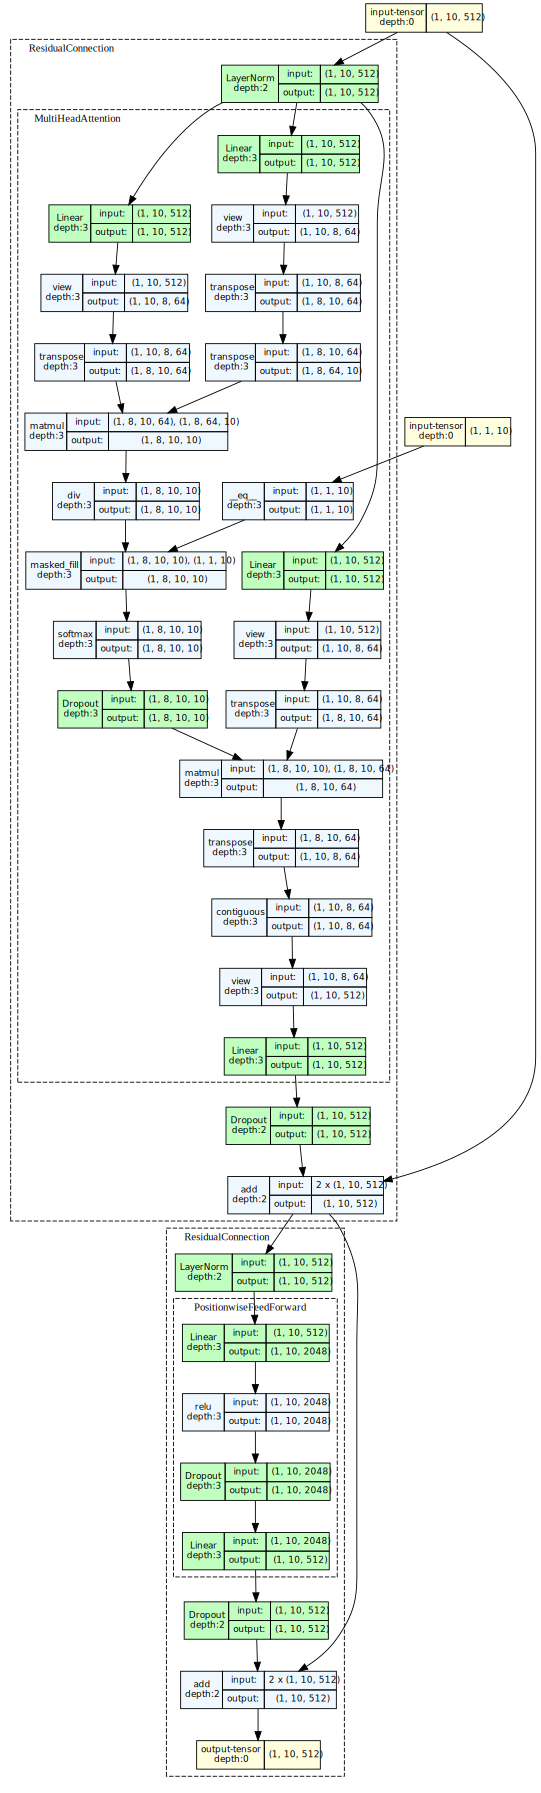

In [13]:
from torchview import draw_graph
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)
try:
    model_graph = draw_graph(
        encoder_layer,
        input_data=(x, x_mask),
        graph_dir='TB', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        expand_nested=True,
        graph_name='Encoder layer',
        save_graph=True,
        filename='encoder_layer_arch',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'encoder_layer_arch.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()

✓ Visualization saved as 'norm_comparison.png'


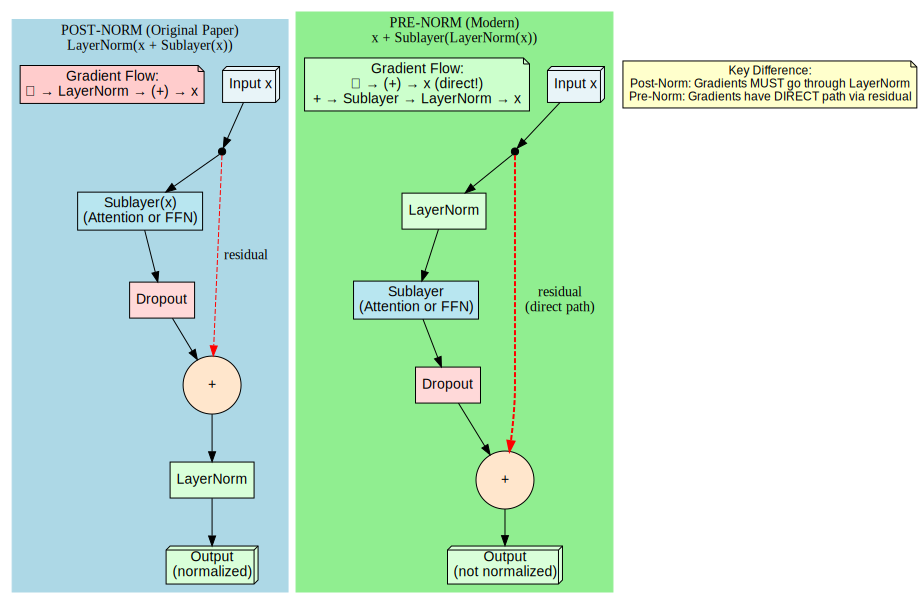

[64452:64452:0417/121222.892459:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[64452:64452:0417/121222.892493:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
from graphviz import Digraph

def visualize_norm_comparison():
    """Visualize Post-Norm vs Pre-Norm side by side"""
    
    dot = Digraph(comment='Normalization Comparison', format='png')
    dot.attr(rankdir='TB', size='14,10')
    dot.attr('node', shape='box', style='filled', fontname='Arial')
    
    # ============================================================
    # Post-Norm (Left side)
    # ============================================================
    
    with dot.subgraph(name='cluster_post') as c:
        c.attr(label='POST-NORM (Original Paper)\nLayerNorm(x + Sublayer(x))', 
               style='filled', color='lightblue', fontsize='14')
        
        c.node('post_input', 'Input x', fillcolor='#E8F4F8', shape='box3d')
        c.node('post_split', '', shape='point', width='0.1')
        c.node('post_sublayer', 'Sublayer(x)\n(Attention or FFN)', fillcolor='#B8E6F0')
        c.node('post_dropout', 'Dropout', fillcolor='#FFD9D9')
        c.node('post_add', '+', fillcolor='#FFE6CC', shape='circle', width='0.8')
        c.node('post_norm', 'LayerNorm', fillcolor='#D9FFD9')
        c.node('post_output', 'Output\n(normalized)', fillcolor='#D9FFD9', shape='box3d')
        
        c.edge('post_input', 'post_split')
        c.edge('post_split', 'post_sublayer')
        c.edge('post_sublayer', 'post_dropout')
        c.edge('post_dropout', 'post_add')
        c.edge('post_split', 'post_add', label='residual', style='dashed', color='red')
        c.edge('post_add', 'post_norm')
        c.edge('post_norm', 'post_output')
        
        # Gradient flow
        c.node('post_grad', 'Gradient Flow:\n∇ → LayerNorm → (+) → x', 
               shape='note', fillcolor='#FFCCCC')
    
    # ============================================================
    # Pre-Norm (Right side)
    # ============================================================
    
    with dot.subgraph(name='cluster_pre') as c:
        c.attr(label='PRE-NORM (Modern)\nx + Sublayer(LayerNorm(x))', 
               style='filled', color='lightgreen', fontsize='14')
        
        c.node('pre_input', 'Input x', fillcolor='#E8F4F8', shape='box3d')
        c.node('pre_split', '', shape='point', width='0.1')
        c.node('pre_norm', 'LayerNorm', fillcolor='#D9FFD9')
        c.node('pre_sublayer', 'Sublayer\n(Attention or FFN)', fillcolor='#B8E6F0')
        c.node('pre_dropout', 'Dropout', fillcolor='#FFD9D9')
        c.node('pre_add', '+', fillcolor='#FFE6CC', shape='circle', width='0.8')
        c.node('pre_output', 'Output\n(not normalized)', fillcolor='#D9FFD9', shape='box3d')
        
        c.edge('pre_input', 'pre_split')
        c.edge('pre_split', 'pre_norm')
        c.edge('pre_norm', 'pre_sublayer')
        c.edge('pre_sublayer', 'pre_dropout')
        c.edge('pre_dropout', 'pre_add')
        c.edge('pre_split', 'pre_add', label='residual\n(direct path)', 
               style='dashed', color='red', penwidth='2.0')
        c.edge('pre_add', 'pre_output')
        
        # Gradient flow
        c.node('pre_grad', 'Gradient Flow:\n∇ → (+) → x (direct!)\n  + → Sublayer → LayerNorm → x', 
               shape='note', fillcolor='#CCFFCC')
    
    # Comparison notes
    dot.node('comparison',
             'Key Difference:\n'
             'Post-Norm: Gradients MUST go through LayerNorm\n'
             'Pre-Norm: Gradients have DIRECT path via residual',
             shape='note', fillcolor='#FFFFCC', fontsize='12')
    
    return dot

# Create visualization
dot_comparison = visualize_norm_comparison()
dot_comparison.render('norm_comparison', view=True, cleanup=True)
print("✓ Visualization saved as 'norm_comparison.png'")
dot_comparison


In [15]:
class Encoder(nn.Module):
    """Encoder stack with N identical layers."""
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(N)])
        self.norm = LayerNorm(layer.d_model)

    def forward(self, x, mask):
        """Pass the input (and mask) through each layer in turn."""
        print(f"+ENCODER: x.shape={x.shape}, mask.shape={mask.shape if mask is not None else None}")
        for layer in self.layers:
            x = layer(x, mask)
        out_encoder = self.norm(x)
        print(f"-ENCODER: output.shape={out_encoder.shape}")
        return out_encoder

In [16]:
batch_size, seq_len,  d_model, h , d_ff, dropout, N = 1, 10, 512, 8, 2048, 0.1, 2
x = torch.randn(batch_size, seq_len, d_model)
mha = MultiHeadAttention(d_model, h, dropout)
ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
encoder_layer = EncoderLayer(d_model, mha, ffn, dropout)
encoder = Encoder(encoder_layer, N)
# mask the pad tokens in the sentence.
x_mask = torch.randn(batch_size, seq_len).unsqueeze(-2)
y = encoder(x, x_mask)

+ENCODER: x.shape=torch.Size([1, 10, 512]), mask.shape=torch.Size([1, 1, 10])
+EN_LAYER: x shape:torch.Size([1, 10, 512]) mask shape: torch.Size([1, 1, 10])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+FFN: x.shape:torch.Size([1, 10, 512])
-FFN:out shape:torch.Size([1, 10, 512])
-RC: output shape: torch.Size([1, 10, 512])
-EN_LAYER: output shape:torch.Size([1, 10, 512])
+EN_LAYER: x

VISUALIZATION 2: Model Architecture (torchview)
+ENCODER: x.shape=torch.Size([1, 10, 512]), mask.shape=torch.Size([1, 1, 10])
+EN_LAYER: x shape:torch.Size([1, 10, 512]) mask shape: torch.Size([1, 1, 10])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+FFN: x.shape:torch.Size([1, 10, 512])
-FFN:out shape:torch.Size([1, 10, 512])
-RC: output shape: torch.Size([1, 10, 512])
-EN_LAYER: ou

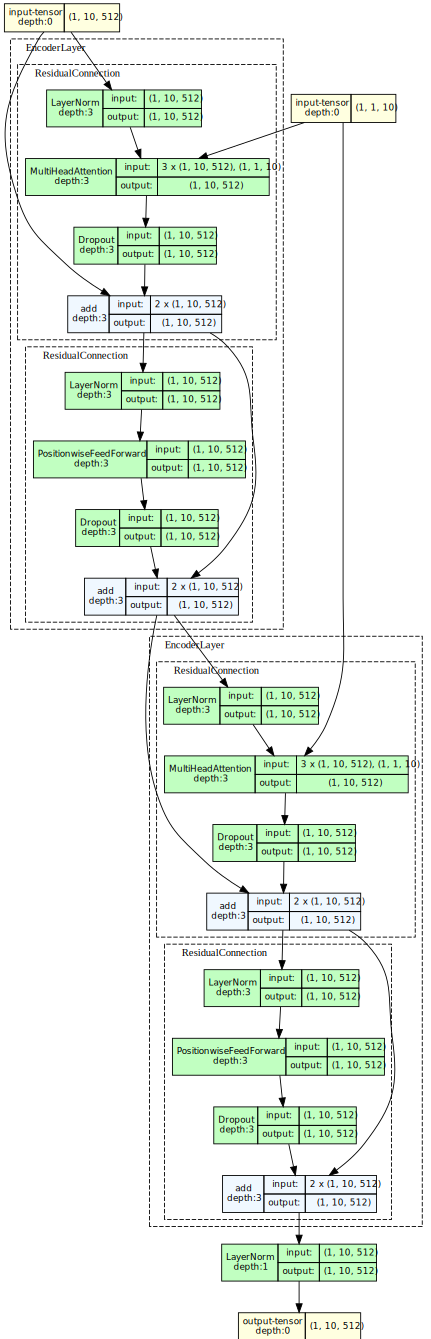

In [17]:
from torchview import draw_graph
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)
try:
    model_graph = draw_graph(
        encoder,
        input_data=(x, x_mask),
        graph_dir='TB', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        expand_nested=True,
        graph_name='Encoder',
        save_graph=True,
        filename='encoder_arch',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'encoder_arch.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()